#### 7.1

In [19]:
import numpy as np

A = np.array([[1, 2, 3],
              [0, -4, 1],
              [0, 3, -1]])

detA = np.linalg.det(A)
print(detA)
# ------------------------------
b = np.array([2, 2, -1])
x = np.linalg.solve(A, b)
print("Solution of A = b:", x)
# -------------------------------
print(A.T @ A) # NOT ORTHOGONAL
# -----------------------------
eigvals, eigvecs = np.linalg.eig(A)
print("Eigenvalues:", eigvals)


1.0
Solution of A = b: [10. -1. -2.]
[[ 1  2  3]
 [ 2 29 -1]
 [ 3 -1 11]]
Eigenvalues: [ 1.         -4.79128785 -0.20871215]


#### 7.3

In [69]:
import numpy as np

def Rz(theta): #Rotation around z-axis
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])

def Ry(theta): #Rotation around y-axis
    return np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

# angles
theta1 = np.deg2rad(192.25)
theta2 = np.deg2rad(90 - 27.4)
theta3 = np.deg2rad(180 - 123)

# compose matrix - z, y, x
E1 = Rz(theta3) @ Ry(theta2) @ Rz(theta1)
E_simple = np.round(E1)
print(E_simple)
print()
# -----------------------------------------
E = np.array([
[-0.06698874, -0.87275577, -0.48353891],
[ 0.49272847, -0.45034696,  0.74458463],
[-0.86760081, -0.1883746 ,  0.46019978]
])

print("I ≈", E.T @ E)         # should be identity
print()
print("Determinant:", round(np.linalg.det(E))) # should be 1
print()
# -----------------------------------
eigvals, eigvecs = np.linalg.eig(E)
print("Eigenvalues:", eigvals)
print()
# -------------------------------------
alpha = np.deg2rad(192.25)
delta = np.deg2rad(27.4)

v = np.array([
    np.cos(delta)*np.cos(alpha),
    np.cos(delta)*np.sin(alpha),
    np.sin(delta)
])

print("Rotational matrix:", v)
print("Norm:", np.linalg.norm(v))
print()
# ----------------------------------------
v2 = E @ v
print(v2)

[[-0.  1.  0.]
 [-0. -0.  1.]
 [ 1. -0.  0.]]

I ≈ [[ 1.00000000e+00 -3.66649539e-09  5.95746769e-09]
 [-3.66649539e-09  1.00000001e+00 -3.38802084e-10]
 [ 5.95746769e-09 -3.38802084e-10  9.99999986e-01]]

Determinant: 1

Eigenvalues: [-0.52856796+0.84889099j -0.52856796-0.84889099j  0.99999999+0.j        ]

Rotational matrix: [-0.86760081 -0.1883746   0.46019978]
Norm: 1.0

[ 3.42052506e-09 -4.54291366e-09  9.99999996e-01]


#### 7.5

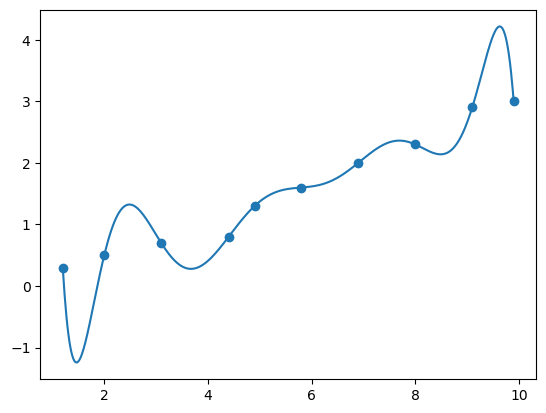

In [23]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)

V = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        V[i, j] = x[i]**j

coeffs = np.linalg.solve(V, y)
# -----------------------------------
def poly(x_val, coeffs):
    y_val = 0
    for i in range(len(coeffs)):
        y_val += coeffs[i] * x_val**i
    return y_val
# -------------------------------------
x_plot = np.linspace(min(x), max(x), 500)
y_plot = [poly(xi, coeffs) for xi in x_plot]

plt.scatter(x, y)
plt.plot(x_plot, y_plot)
plt.show()

#### 7.6

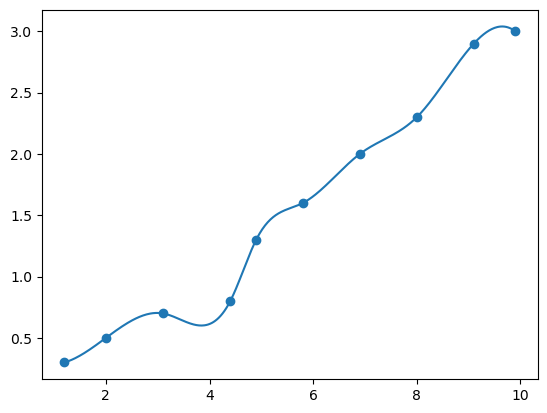

Linear (Value of 5.5) - 1.5
Polynomial (Value of5.5) - 1.5702983233305758
Spline (Value of 5.5) - 1.5491249272587813


Enter value of x_hat:  5.5
Choose method (linear / polynomial / spline):  linear


Interpolated value (method=linear): 1.5


In [39]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

spline = interp1d(x, y, kind='cubic')

x_plot = np.linspace(min(x), max(x), 500)
y_spline = spline(x_plot)

plt.scatter(x, y)
plt.plot(x_plot, y_spline)
plt.show()
# -----------------------------------
class Interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
        # polynomial
        n = len(self.x)
        V = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                V[i, j] = self.x[i]**j
        self.coeffs = np.linalg.solve(V, self.y)
        
        # spline
        self.spline = interp1d(self.x, self.y, kind='cubic')
        
        # linear
        self.linear = interp1d(self.x, self.y, kind='linear')
    
    def evaluate(self, x_val, method='linear'):
        if method == 'linear':
            return self.linear(x_val)
        elif method == 'polynomial':
            y_val = 0
            for i in range(len(self.coeffs)):
                y_val += self.coeffs[i]*x_val**i
            return y_val
        elif method == 'spline':
            return self.spline(x_val)

interp = Interpolation(x, y)

# For values 5.5 as \hat(x)
print("Linear (Value of 5.5) -",interp.evaluate(5.5, 'linear'))
print("Polynomial (Value of5.5) -", interp.evaluate(5.5, 'polynomial'))
print("Spline (Value of 5.5) -", interp.evaluate(5.5, 'spline'))

# -----------------------------------
# User input
x_hat = float(input("Enter value of x_hat: "))
method = input("Choose method (linear / polynomial / spline): ").strip().lower()

# Compute result
y_hat = interp.evaluate(x_hat, method)

print(f"Interpolated value (method={method}): {y_hat}")

Cubic spline interpolation provides a smoother and more stable curve.


#### 7.7

In [42]:
import numpy as np
I = np.array([[2.0, 4.1],
              [2.5, 3.8]])

# Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
x, y = 0.2, 0.7
# x = mu (Horizontal interpolation parameter), y = lambda (vertical interpolation parameter)
I_interp = (1-y)*(1-x)*I[0,0] + y*(1-x)*I[1,0] + x*(1-y)*I[0,1] + x*y*I[1,1]

print(I_interp)

2.658


In [45]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)
I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


#### 7.10

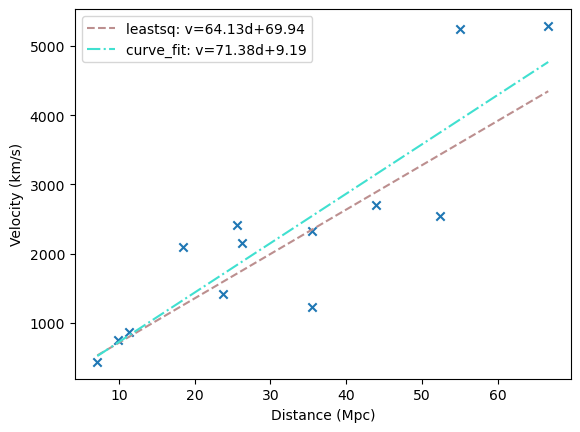

In [67]:
import numpy as np
from scipy.optimize import leastsq
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

data = np.array([
   18.49,2094.75,0.3,100,
   35.48,2320.87,2.2,120,
   35.48,1224.9,3.0,80,
   11.34,872.13,1.2,80,
   7.12,432.2,0.4,70,
   9.82,751,0.3,75,
   23.66,1410,2.3,70,
   44,2700,4.0,110,
   66.7,5292,5.3,120,
   52.4,2550,5.2,100,
   55,5253,6.1,150,
   25.6,2419,3.2,110,
   26.19,2158,2.8,110
])

data = data.reshape(-1,4)

d = data[:,0]
v = data[:,1]
sigma_v = data[:,3]

# -------------------
def model(p, d):
    H0, c = p
    return H0*d + c
# ----------------------------
def residuals(p, d, v, sigma):
    return (v - model(p, d)) / sigma

p0 = [70.0, 0] #Initial Guess
params, _ = leastsq(residuals, p0, args=(d, v, sigma_v))

H0_ls, c_ls = params
# ------------------------------
def f(d, H0, c):
    return H0*d + c

params_cf, _ = curve_fit(f, d, v)

H0_cf, c_cf = params_cf

# ------------------------------------
plt.scatter(d, v, marker='x')

d_fit = np.linspace(min(d), max(d), 200)

plt.plot(d_fit, f(d_fit, H0_ls, c_ls),
         label=f"leastsq: v={H0_ls:.2f}d+{c_ls:.2f}", linestyle='--', color='rosybrown')

plt.plot(d_fit, f(d_fit, H0_cf, c_cf),
         label=f"curve_fit: v={H0_cf:.2f}d+{c_cf:.2f}", linestyle='-.', color='turquoise')

plt.xlabel("Distance (Mpc)")
plt.ylabel("Velocity (km/s)")
plt.legend()
plt.show()

====== LEASTSQ RESULTS ==========
Params:                          [69.93805979 64.13233494]
Unscaled standard error(s):      [47.32288249  1.52711792]
Scaled standard error(s):        [348.23437453  11.23758582]
Degrees of freedom:              11
Chi^2 min:                       595.6533407328835
Reduced Chi squared:             54.15030370298941
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7


NameError: name 'beta_lsqwei' is not defined

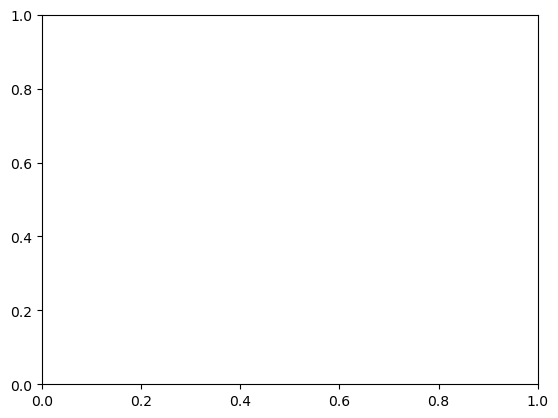

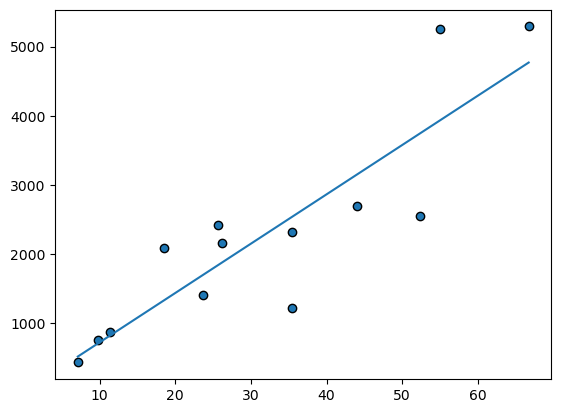

In [60]:
import numpy as np
from scipy.optimize import leastsq
from matplotlib.pyplot import figure, show

# ---------------- Model ----------------
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1 * x

# ---------------- Residuals (weighted) ----------------
def residuals(beta, x, y, yerr):
    return (y - model(beta, x)) / yerr

# ---------------- Data ----------------
data = np.array([
   18.49, 2094.75, 0.3, 100,
   35.48, 2320.87, 2.2, 120,
   35.48, 1224.9, 3.0, 80,
   11.34, 872.13, 1.2, 80,
   7.12, 432.2, 0.4, 70,
   9.82, 751, 0.3, 75,
   23.66, 1410, 2.3, 70,
   44, 2700, 4.0, 110,
   66.7, 5292, 5.3, 120,
   52.4, 2550, 5.2, 100,
   55, 5253, 6.1, 150,
   25.6, 2419, 3.2, 110,
   26.19, 2158, 2.8, 110
])

# ---------------- Extract columns ----------------
d = data[0::4]      # distances
v = data[1::4]      # velocities
d_err = data[2::4]  # distance errors (not used here)
v_err = data[3::4]  # velocity errors (used for weighting)

# ---------------- Fit ----------------
beta_start = [0, 70.0]

result = leastsq(residuals, beta_start, args=(d, v, v_err), full_output=1)
(beta, pcov, infodict, errmsg, ier) = result

# ---------------- Error analysis ----------------
if pcov is not None:
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())
    dof = len(fvec) - len(beta)

    sderr = perror * np.sqrt(chi2 / dof)

# ---------------- PRINT BLOCK (unchanged style) ----------------
print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

# -----------------------------------------------
fig = figure()
frame = fig.add_subplot(1,1,1)

# Data points
# ------------------------
def residuals_unweighted(beta, x, y):
    return y - model(beta, x)

result_lsq = leastsq(residuals_unweighted, beta_start, args=(d, v), full_output=1)
beta_lsq, pcov_lsq, infodict_lsq, errmsg_lsq, ier_lsq = result_lsq

def residuals_robust(beta, x, y):
    r = y - model(beta, x)
    
    # Huber threshold
    delta = 1.0
    
    # Apply robust weighting
    return np.where(np.abs(r) < delta, r, delta * np.sign(r))

result_robust = leastsq(residuals_robust, beta_start, args=(d, v), full_output=1)
beta_robust, pcov_robust, infodict_robust, errmsg_robust, ier_robust = result_robust

fig = figure()
frame = fig.add_subplot(1,1,1)

# Data
frame.scatter(d, v, marker='o', edgecolor='k', label="Data")

# X range
xmin = d.min()
xmax = d.max()
x_fit = np.linspace(xmin, xmax, 200)

# Models
frame.plot(x_fit, model(beta_lsq, x_fit), label="Normal fit")
frame.plot(x_fit, model(beta_lsqwei, x_fit), label="Weighted fit")
frame.plot(x_fit, model(beta_robust, x_fit), label="Robust fit")

frame.set_xlabel('Distance (Mpc)')
frame.set_ylabel('Velocity (km/s)')
frame.grid()
frame.legend()

show()